# Digital Twin of VR-1 Lab
## Sree Gudala

We will be attempting to create a Reduced Order Model (Method of Snapshots specifically) of the VR-1 reactor. The steps to do so are numbered below. Please run the cells sequentially.

# 0th Problem: Compute Snapshots
Sample your parameter space and use your high-fidelity code to model each of these cases.
* Our hi-fi code is OpenMC
* The parameters we are varying are control rod 1 and 2 height (between z=0 and z=84.7), water density in a fuel assembly and a dummy channel (btwn 0.50 and 1.00 * normal water density)
* For time-efficiency and consistency, I've pre-computed our training and test data.
* Store the "VR1_DT_Lab_Training_Data" and "VR1_DT_Lab_Test_Data" directories in the same directory as this file ("dt_lab.ipynb")

In [1]:
"""
Environment Setup: This notebook is designed to be run in a Jupyter environment with Python 3. It requires the following libraries:
- numpy
- pandas
- matplotlib
- scikit-learn
- ipykernel
- ipywidgets
- ipython
- if not already installed, you can install them using pip:
````
pip install numpy pandas matplotlib scikit-learn ipykernel ipywidgets ipython
````
- or conda:
````
conda activate your_environment_name (probably vr1-openmc)
conda install numpy pandas matplotlib scikit-learn ipykernel ipywidgets ipython
````
"""

%matplotlib inline
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import sklearn.ensemble as ensemble
from sklearn.metrics import mean_squared_error
import sklearn.neural_network as nn
import ipywidgets as widgets
from IPython.display import display, clear_output


# Plotting aesthetics
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

In [2]:
"""
Loading & Reshaping OpenMC Data

Unpacks the .npz dictionaries, extracts the thermal and fast flux vectors, and reshapes them into OpenMC’s native 4D array layout (Z, Y, X, Energy).
"""

# Mesh dimensions defined in the OpenMC model
NX, NY, NZ, NG = 60, 60, 70, 2

def load_flux_data(file_path):
    """Loads an NPZ file and reconstructs the 4D flux array."""
    with np.load(file_path) as data:
        thermal = data['thermal_flux']
        fast = data['fast_flux']
        
        # OpenMC mesh bins iterate X fastest, then Y, then Z.
        # To reshape correctly in Python, Z must be the slowest (first) axis.
        thermal_3d = thermal.reshape((NZ, NY, NX))
        fast_3d = fast.reshape((NZ, NY, NX))
        
        # Stack them to create a (NZ, NY, NX, NG) array
        combined_flux = np.stack([thermal_3d, fast_3d], axis=-1)
        
        return combined_flux

# Example: Load the first training case
flux_case_1 = load_flux_data('VR1_DT_Lab_Training_Data/results_case_1.npz') 
print(f"Flux array shape: {flux_case_1.shape}") # Will print (70, 60, 60, 2)

Flux array shape: (70, 60, 60, 2)


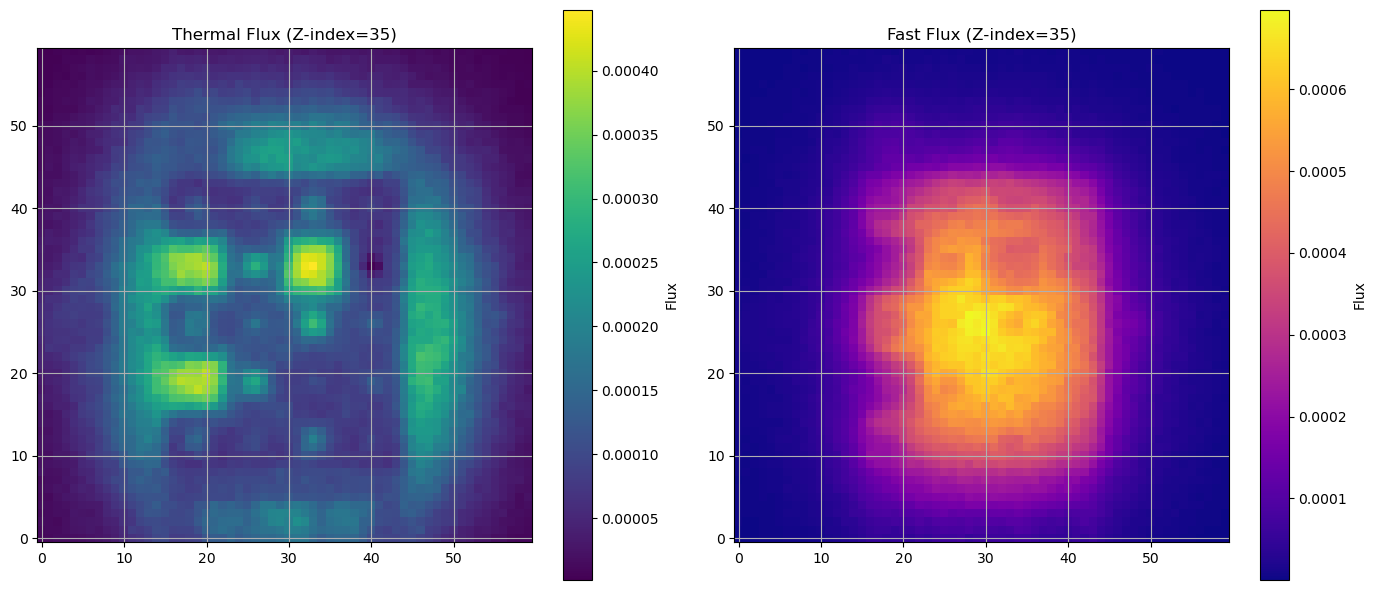

In [3]:
"""
Visualizing Flux Slices

Plots the thermal and fast flux at a specific Z-height to verify the data integrity and understand the spatial distribution of the fluxes.
"""
def plot_flux_slice(flux_array, z_index=35):
    assert z_index < flux_array.shape[0], "Z-index out of bounds for the flux array. Z should be less than 70."

    """Plots the thermal and fast flux at a specific Z-height."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Slicing flux_array[z_index, :, :, g] returns a 2D array of shape (NY, NX).
    # imshow natively expects (rows, columns) which perfectly matches our (Y, X).
    
    # Thermal Flux (Group 0)
    im0 = axes[0].imshow(flux_array[z_index, :, :, 0], origin='lower', cmap='viridis')
    axes[0].set_title(f'Thermal Flux (Z-index={z_index})')
    fig.colorbar(im0, ax=axes[0], label='Flux')
    
    # Fast Flux (Group 1)
    im1 = axes[1].imshow(flux_array[z_index, :, :, 1], origin='lower', cmap='plasma')
    axes[1].set_title(f'Fast Flux (Z-index={z_index})')
    fig.colorbar(im1, ax=axes[1], label='Flux')
    
    plt.tight_layout()
    plt.show()

# Plot the flux slices for the first case
plot_flux_slice(flux_case_1, z_index=35)


In [4]:
"""
Loading Training & Test Data

Reads the input features from the CSV files and extracts the k-effective targets from the corresponding NPZ
"""

# Load the parameters
train_df = pd.read_csv('VR1_DT_Lab_Training_Data/training_set.csv')
test_df = pd.read_csv('VR1_DT_Lab_Test_Data/test_set.csv')

# 1. Load the input features from the CSVs
features = [
    'cr1_height', 
    'cr2_height', 
    'dummy_water_density_multiplier', 
    'fuel_assembly_water_density_multiplier'
]

X_train = train_df[features].values
X_test = test_df[features].values

# 2. Extract k-effective from the NPZ files
# We iterate over the 'case_id' column to guarantee the arrays match perfectly
def extract_keff(dataframe, folder_path):
    keff_values = []
    for case in dataframe['case_id']:
        # Construct the file path using the case_id
        file_path = f"{folder_path}/results_case_{case}.npz"
        
        # Open the file and grab just the keff scalar
        with np.load(file_path) as data:
            keff_values.append(data['keff'])
            
    return np.array(keff_values)

# Pull targets from their respective folders
y_train_keff = extract_keff(train_df, 'VR1_DT_Lab_Training_Data')
y_test_keff = extract_keff(test_df, 'VR1_DT_Lab_Test_Data')

# 1st Problem: Parameter Sensitivity Study

Plot the 2D x-y flux for at least three OpenMC simulation cases (or just use the three I've selected) and answer these questions:

1. What do you see? What does the flux distribution look like? What is the physical explanation behind the visual observation?
2. What changes for different cases? What stays the same?
3. Change the height (z_index variable, check at (0, 35, 68), etc...), rerun the cell, and see what happens

   case_id  cr1_height  cr2_height  dummy_water_density_multiplier  \
0        1   58.306195   76.042484                        0.745345   

   fuel_assembly_water_density_multiplier  
0                                0.611456  
K-effective for case 1: 1.00263


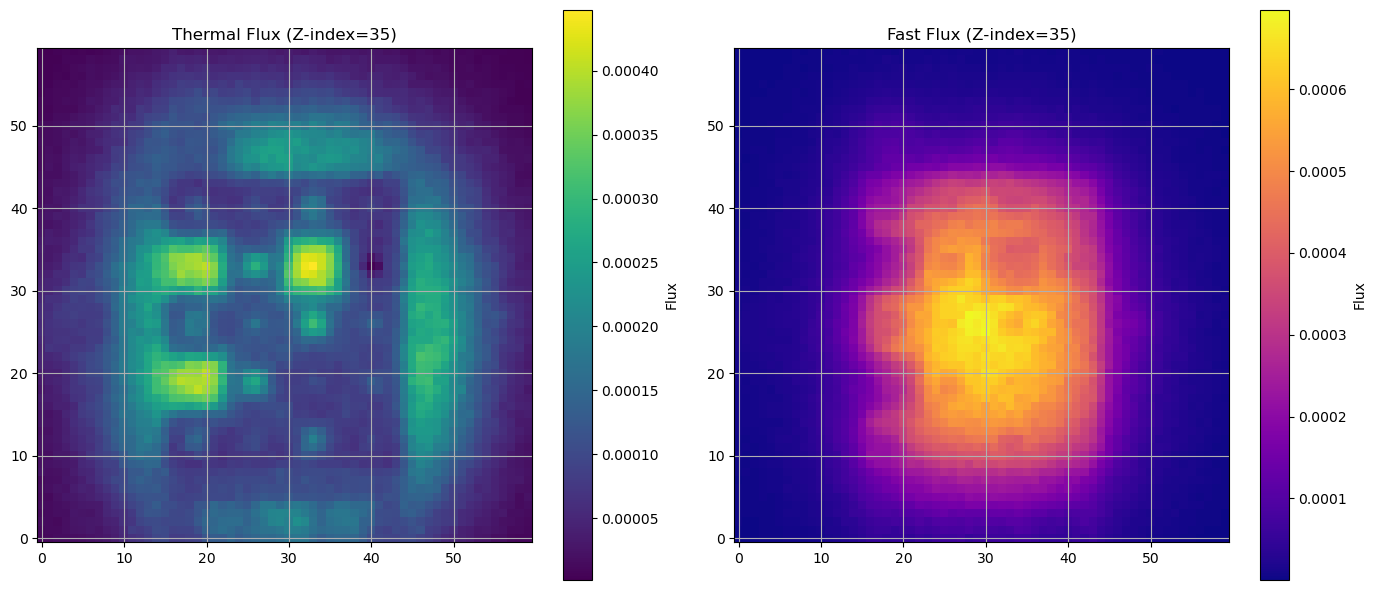

    case_id  cr1_height  cr2_height  dummy_water_density_multiplier  \
11       12   17.009111    8.925082                         0.80173   

    fuel_assembly_water_density_multiplier  
11                                0.518009  
K-effective for case 12: 0.98194


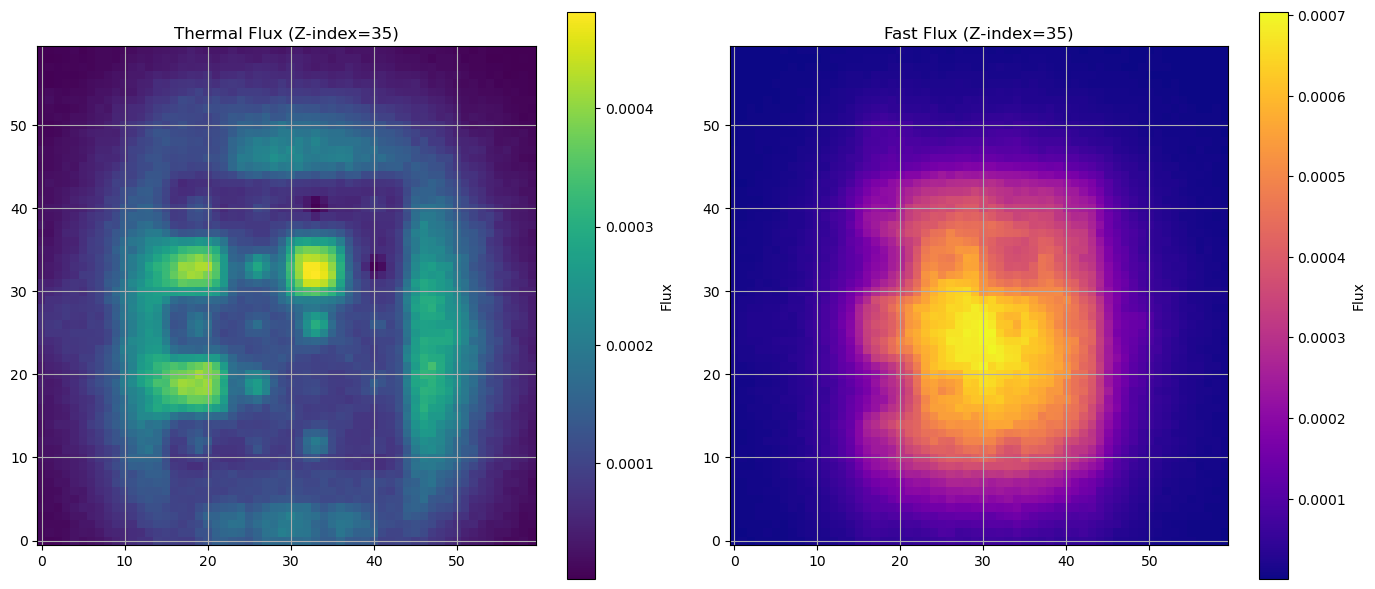

    case_id  cr1_height  cr2_height  dummy_water_density_multiplier  \
88       89    3.113788   18.376399                        0.511376   

    fuel_assembly_water_density_multiplier  
88                                0.893696  
K-effective for case 66: 0.99288


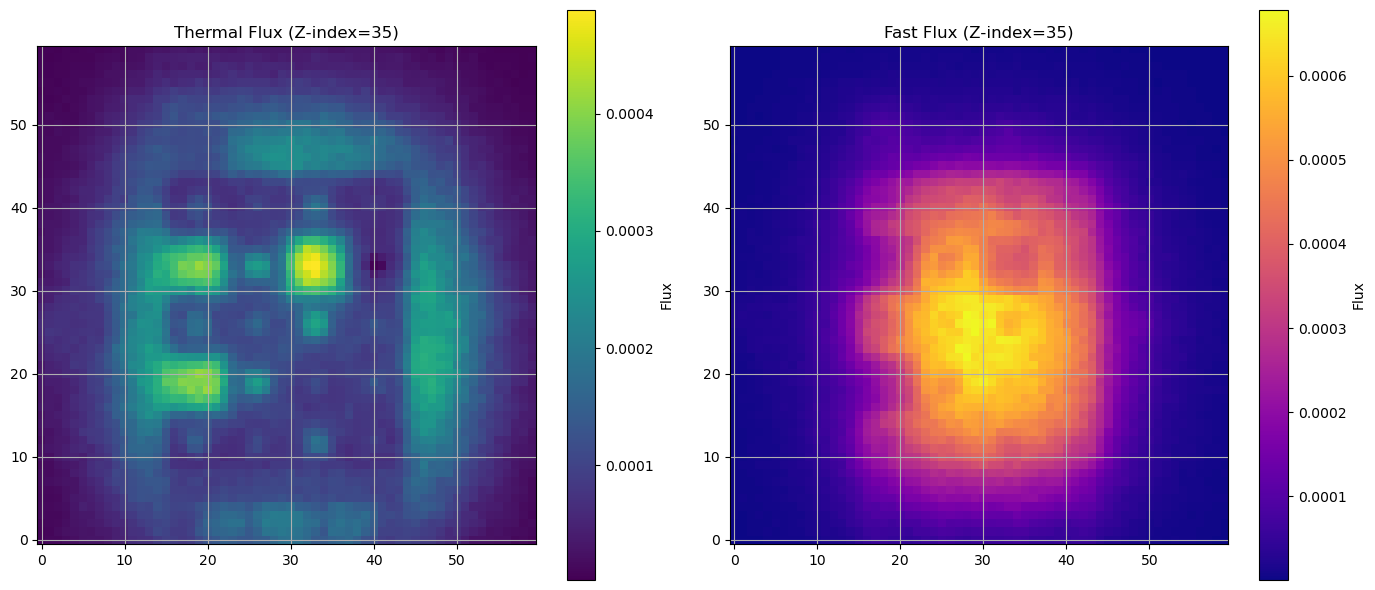

In [5]:
# Load the cases for visualization
flux_case_1 = load_flux_data('VR1_DT_Lab_Training_Data/results_case_1.npz') 
flux_case_12 = load_flux_data('VR1_DT_Lab_Training_Data/results_case_33.npz')
flux_case_89 = load_flux_data('VR1_DT_Lab_Training_Data/results_case_66.npz')

z_index = 35  # Mid-plane index (Z ranges from 0 to 69)

# Visualize mid-plane (Z ranges from 0 to 69, so 35 is roughly the middle) and compare across cases
# Also print parameters for reference (from VR1_DT_Lab_Training_Data/training_set.csv)
training_params = pd.read_csv('VR1_DT_Lab_Training_Data/training_set.csv')
print(training_params.loc[[0]])  # Print parameters for case 1
print(f"K-effective for case 1: {y_train_keff[0]:.5f}")
plot_flux_slice(flux_case_1, z_index)
print(training_params.loc[[11]])  # Print parameters for case 12
print(f"K-effective for case 12: {y_train_keff[11]:.5f}")
plot_flux_slice(flux_case_12, z_index)
print(training_params.loc[[88]])  # Print parameters for case 66
print(f"K-effective for case 66: {y_train_keff[88]:.5f}")
plot_flux_slice(flux_case_89, z_index)

# 2nd Problem: K-eff Multi-variate regression

Before we try to predict the full flux map, we predict k-eff for the VR-1 based off the parameters.

I've extracted the training and test data and stored them in the variables below. 
I've included some different models (LinearRegression, PolynomialRegression, RandomForest).

Uncomment each model (and vary the model hyperparameters if you are interested) and observe how the error (RMSE) changes.

1. Which model is the best? How do you know?

K-effective Prediction RMSE: 0.00189


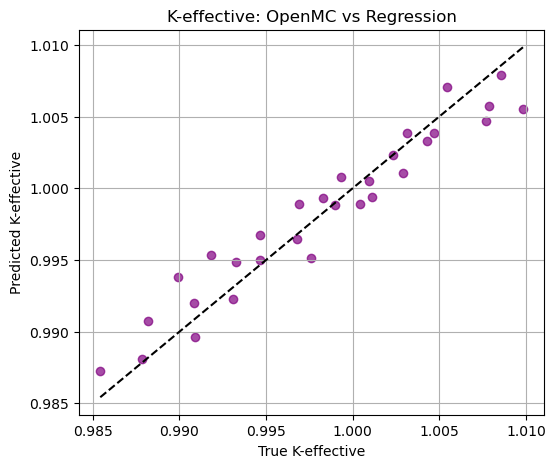

In [6]:
# Define training and test data here
X_train = train_df[features].values
X_test = test_df[features].values

y_train_keff = extract_keff(train_df, 'VR1_DT_Lab_Training_Data')
y_test_keff = extract_keff(test_df, 'VR1_DT_Lab_Test_Data')




"""
Change which regression model you use here to see how it affects the prediction error.
"""

# Train a simple Linear Regression model
# keff_model = LinearRegression()

# Train a NON-LINEAR Surrogate for k-effective instead
# A degree-3 polynomial allows for the classic S-Curve of rod worth
# keff_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# (Alternatively, try a Random Forest here too)
keff_model = ensemble.RandomForestRegressor(n_estimators=100, random_state=42)






keff_model.fit(X_train, y_train_keff)


# Evaluate the prediction error
predictions = keff_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_keff, predictions))
print(f"K-effective Prediction RMSE: {rmse:.5f}")

# Optional: Plot the correlation
plt.figure(figsize=(6, 5))
plt.scatter(y_test_keff, predictions, alpha=0.7, color='purple')
plt.plot([y_test_keff.min(), y_test_keff.max()], 
         [y_test_keff.min(), y_test_keff.max()], 'k--')
plt.title('K-effective: OpenMC vs Regression')
plt.xlabel('True K-effective')
plt.ylabel('Predicted K-effective')
plt.grid(True)
plt.show()

# 3rd Problem: ROM for k-effective

Play with the widget and see how k-eff changes.

What happens to k-eff when:

1. Control rod 1 height increases
2. Control rod 2 height increases
3. Fuel assembly water density decreases
4. Dummy assembly water density decreases

Why?

In [7]:
"""
Interactive Digital Twin Interface for k-eff

Creates an interactive widget that allows users to adjust the control rod heights and water density multipliers, and then predicts the k-effective using the trained surrogate model. 
The interface updates in real-time as the sliders are adjusted, providing immediate feedback on how changes in the operating state affect the reactor's criticality.
"""

def run_digital_twin(cr1, cr2, dummy_water, fa_water):
    """Predicts and displays only k-effective for the selected operating state."""
    input_state = np.array([[cr1, cr2, dummy_water, fa_water]])
    predicted_keff = keff_model.predict(input_state)[0]

    clear_output(wait=True)
    display(interactive_keff)
    print(f"Estimated k-effective: {predicted_keff:.5f}")

interactive_keff = widgets.interactive(
    run_digital_twin,
    cr1=widgets.FloatSlider(value=42.35, min=0.0, max=84.7, step=0.1, description='CR 1 (cm):'),
    cr2=widgets.FloatSlider(value=42.35, min=0.0, max=84.7, step=0.1, description='CR 2 (cm):'),
    dummy_water=widgets.FloatSlider(value=1.00, min=0.50, max=1.00, step=0.01, description='Dummy Water:'),
    fa_water=widgets.FloatSlider(value=1.00, min=0.50, max=1.00, step=0.01, description='FA Water:')
)

display(interactive_keff)

interactive(children=(FloatSlider(value=42.35, description='CR 1 (cm):', max=84.7), FloatSlider(value=42.35, d…

# 4th Problem: Use ROM to do Sensitivity Analysis

Using this ROM, we can do analysis like rod worth calculations much quicker than if we were to run OpenMC for each case.

The caveat is that this sensitivity analysis is only as good as our regression model. We can make it "look" however we want by changing the model.

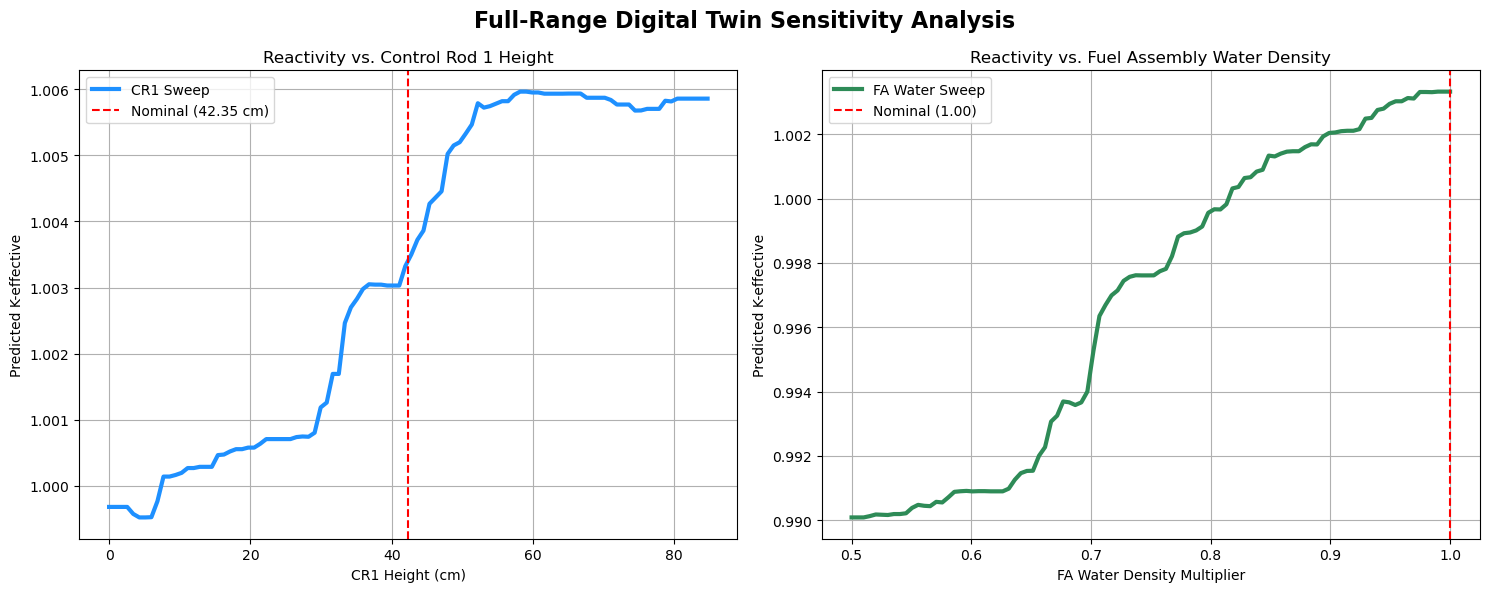

In [8]:
"""Full-Range Sensitivity Analysis"""

# 1. Define the nominal "steady state" based on your exact bounds
nominal_cr = 84.7 / 2  # Midpoint insertion
nominal_water = 1.00   # Fully dense water

nominal_inputs = np.array([[nominal_cr, nominal_cr, nominal_water, nominal_water]])
nominal_keff = keff_model.predict(nominal_inputs)[0]

# 2. Create the precise full-range sweeps
steps = 100
cr_sweep_vals = np.linspace(0.0, 84.7, steps)
water_sweep_vals = np.linspace(0.50, 1.00, steps)

# 3. Build the arrays (Holding other variables at nominal)
sweep_cr1_array = np.zeros((steps, 4)) + nominal_inputs
sweep_cr1_array[:, 0] = cr_sweep_vals

sweep_fa_array = np.zeros((steps, 4)) + nominal_inputs
sweep_fa_array[:, 3] = water_sweep_vals

# 4. Predict k-effective using the surrogate
keff_cr1_vals = keff_model.predict(sweep_cr1_array)
keff_fa_vals = keff_model.predict(sweep_fa_array)

# 5. Plot the Full-Range Sensitivity
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Control Rod Sweep
axes[0].plot(cr_sweep_vals, keff_cr1_vals, lw=3, color='dodgerblue', label='CR1 Sweep')
axes[0].axvline(nominal_cr, color='red', linestyle='--', label='Nominal (42.35 cm)')
axes[0].set_title('Reactivity vs. Control Rod 1 Height')
axes[0].set_xlabel('CR1 Height (cm)')
axes[0].set_ylabel('Predicted K-effective')
axes[0].grid(True)
axes[0].legend()

# Subplot 2: Fuel Assembly Water Sweep
axes[1].plot(water_sweep_vals, keff_fa_vals, lw=3, color='seagreen', label='FA Water Sweep')
axes[1].axvline(nominal_water, color='red', linestyle='--', label='Nominal (1.00)')
axes[1].set_title('Reactivity vs. Fuel Assembly Water Density')
axes[1].set_xlabel('FA Water Density Multiplier')
axes[1].set_ylabel('Predicted K-effective')
axes[1].grid(True)
axes[1].legend()

plt.suptitle('Full-Range Digital Twin Sensitivity Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5th Problem: Assemble Snapshot Matrix of Flux and compute SVD

Now, let's try to create a ROM of the flux maps

Look at the graph of how much variance is stored in each successive flux mode.

1. What is this graph telling us?
2. Where should we cut off the modes to balance keeping information and compression?

Found 100 training files. Building matrix...
Snapshot Matrix Shape: (504000, 100)


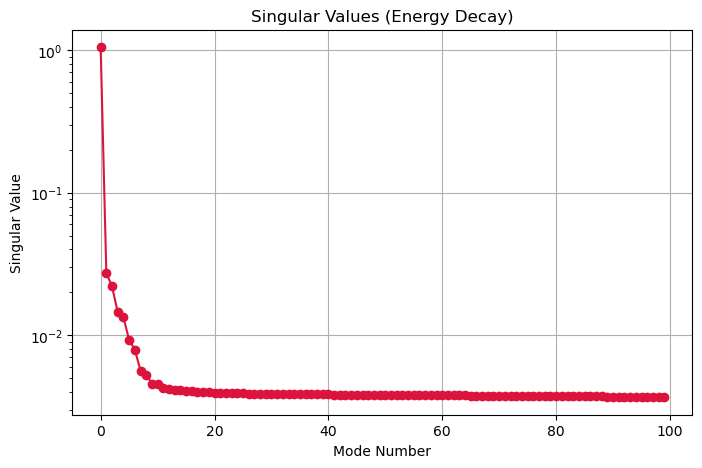

In [9]:
"""Building the Snapshot Matrix for POD"""

train_files = glob.glob('VR1_DT_Lab_Training_Data/results_case_*.npz')
train_files.sort(key=lambda f: int(re.search(r'case_(\d+)', f).group(1)))

print(f"Found {len(train_files)} training files. Building matrix...")



# Build the Snapshot Matrix
S_matrix = []
for f in train_files:
    # Use our fixed function to get the properly shaped 4D array
    flux_4d = load_flux_data(f)
    
    # Flatten it into a single 1D vector
    flux_flat = flux_4d.flatten()
    S_matrix.append(flux_flat)


# Stack columns
S_matrix = np.column_stack(S_matrix)
print(f"Snapshot Matrix Shape: {S_matrix.shape}") 

# Perform SVD (Truncated to save memory/time)
# S_matrix = U * diag(Sigma) * V^T
U, Sigma, VT = np.linalg.svd(S_matrix, full_matrices=False)

# Plot the singular values to show energy drop-off
plt.figure(figsize=(8, 5))
plt.semilogy(Sigma, marker='o', color='crimson')
plt.title('Singular Values (Energy Decay)')
plt.xlabel('Mode Number')
plt.ylabel('Singular Value')
plt.grid(True)
plt.show()

# 6th Problem: Plot the Flux Modes

These modes are the most dominant patterns in our data. We can use these to reconstruct any of our training cases with high accuracy. The goal is to use them to train a regression model to predict teh flux shapes for any parameter configuration.

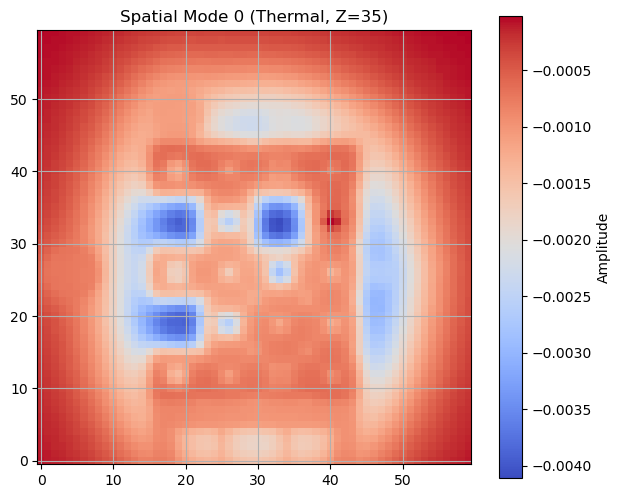

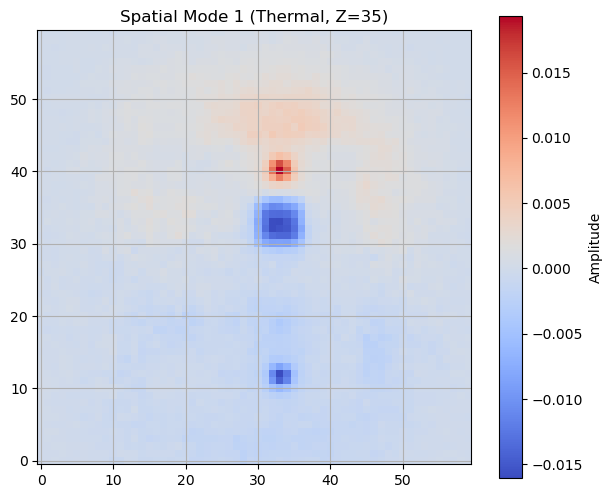

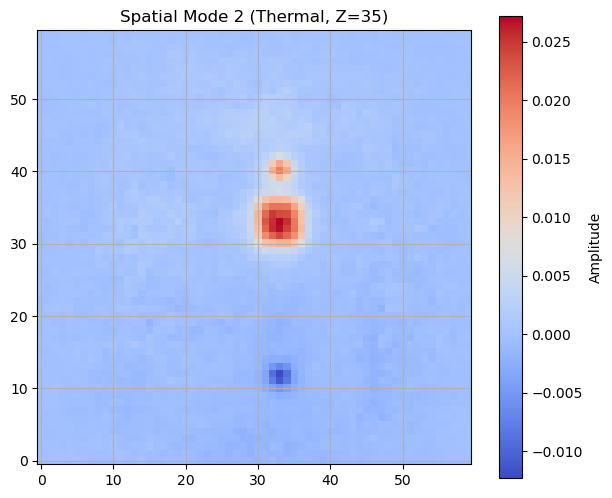

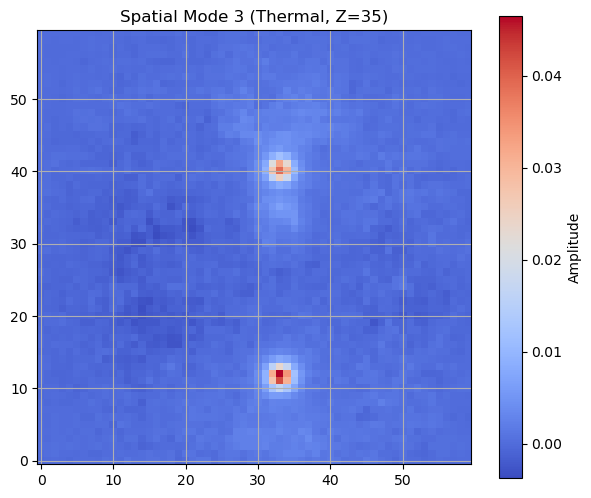

In [10]:
def plot_mode(U_matrix, mode_idx, z_index=35):
    # Extract the mode and reshape it back to the proper 4D OpenMC layout
    mode_flat = U_matrix[:, mode_idx]
    
    # CORRECTED SHAPE: (Z, Y, X, Energy)
    mode_3d = mode_flat.reshape((NZ, NY, NX, NG))
    
    plt.figure(figsize=(7, 6))
    
    # Slice exactly at z_index. No transpose (.T) needed anymore!
    plt.imshow(mode_3d[z_index, :, :, 0], origin='lower', cmap='coolwarm')
    
    plt.colorbar(label='Amplitude')
    plt.title(f'Spatial Mode {mode_idx} (Thermal, Z={z_index})')
    plt.show()

plot_mode(U, 0) # Fundamental
plot_mode(U, 1) # First major tilt
plot_mode(U, 2) # Second major tilt
plot_mode(U, 3) # Third major tilt

# 7th Problem: Create Flux ROM and choose Regression Model

Change the regression model to see what fits best.
The error can be found by running the next cell.

1. What model should we use?

In [13]:
# 1. Project the Training Data onto the Reduced Basis
# We only keep the first 'r' modes to filter out high-frequency noise
r = 10 
U_r = U[:, :r]

# Calculate the modal coefficients for the training set: C = U_r^T * S
# Shape becomes (r_modes, n_samples)
C_train = np.dot(U_r.T, S_matrix)

# Scikit-learn expects target variables in the shape (n_samples, n_targets)
Y_train_coeffs = C_train.T 


# 2. Define the Surrogate Model
""" 
======================================================================
# EXPLORATION ZONE: 
# Below are different types of regression models. Comment/Uncomment 
# to explore how well they capture the non-linear physics of the core!
======================================================================
"""

# Option A: Standard Multiple Linear Regression
# (Spoiler: This might struggle with control rod S-curves!)
# surrogate_model = LinearRegression()

# Option B: Polynomial Regression (Degree 2)
# Adds interaction terms (e.g., cr1_height * water_density) and squared terms
# surrogate_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# Option C: Random Forest Regressor (Non-linear, tree-based)
surrogate_model = ensemble.RandomForestRegressor(n_estimators=100, random_state=42)

# Option D: Multi-Layer Perceptron (A small Neural Network)
# surrogate_model = nn.MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000)




# 3. Train the Model
# X_train comes from the training_params.csv loaded earlier
surrogate_model.fit(X_train, Y_train_coeffs)
print(f"Surrogate Model Trained using {surrogate_model.__class__.__name__}")

Surrogate Model Trained using RandomForestRegressor


In [14]:
# 1. Calculate the true coefficients for the test set
S_matrix_test = []

# Iterate over the case_id to guarantee alignment with X_test
for case in test_df['case_id']:
    file_path = f"VR1_DT_Lab_Test_Data/results_case_{case}.npz"
    
    # Use our robust function to load the 4D array, then flatten it
    flux_4d = load_flux_data(file_path)
    S_matrix_test.append(flux_4d.flatten())

# Stack into the (504000, N_test_cases) matrix
S_matrix_test = np.column_stack(S_matrix_test)

# Project test data onto the training basis to get the 'True' modal coefficients
# C = U_r^T * S_test
Y_test_coeffs_true = np.dot(U_r.T, S_matrix_test).T

# 2. Predict coefficients using only the 4 physical parameters
Y_test_coeffs_pred = surrogate_model.predict(X_test)

# 3. Evaluate the error across all 'r' modes
mse = mean_squared_error(Y_test_coeffs_true, Y_test_coeffs_pred)
print(f"Mean Squared Error of Modal Coefficients: {mse:.4e}")

# # Optional: Plot True vs Predicted for Mode 1 (The first big flux tilt)
# plt.figure(figsize=(6, 6))
# plt.scatter(Y_test_coeffs_true[:, 1], Y_test_coeffs_pred[:, 1], alpha=0.7, color='dodgerblue')

# # Draw the perfect prediction diagonal line
# min_val = Y_test_coeffs_true[:, 1].min()
# max_val = Y_test_coeffs_true[:, 1].max()
# plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Fit')

# plt.xlabel('True Mode 1 Coefficient')
# plt.ylabel('Predicted Mode 1 Coefficient')
# plt.title('Surrogate Accuracy: Mode 1 (Flux Tilt)')
# plt.legend()
# plt.grid(True)
# plt.show()

Mean Squared Error of Modal Coefficients: 2.1305e-07


# 8th Problem: How does our Flux Regression Model perform?

Run the regression model on test cases (change test_idx to 3, 5, 6 for example) to see how good the model is.

1. Where is the model performing well and where are the predictions poor?

Simulating VR-1 State: Rods=[83.03755649 64.29706545], Water=[0.75452405 0.54342408]


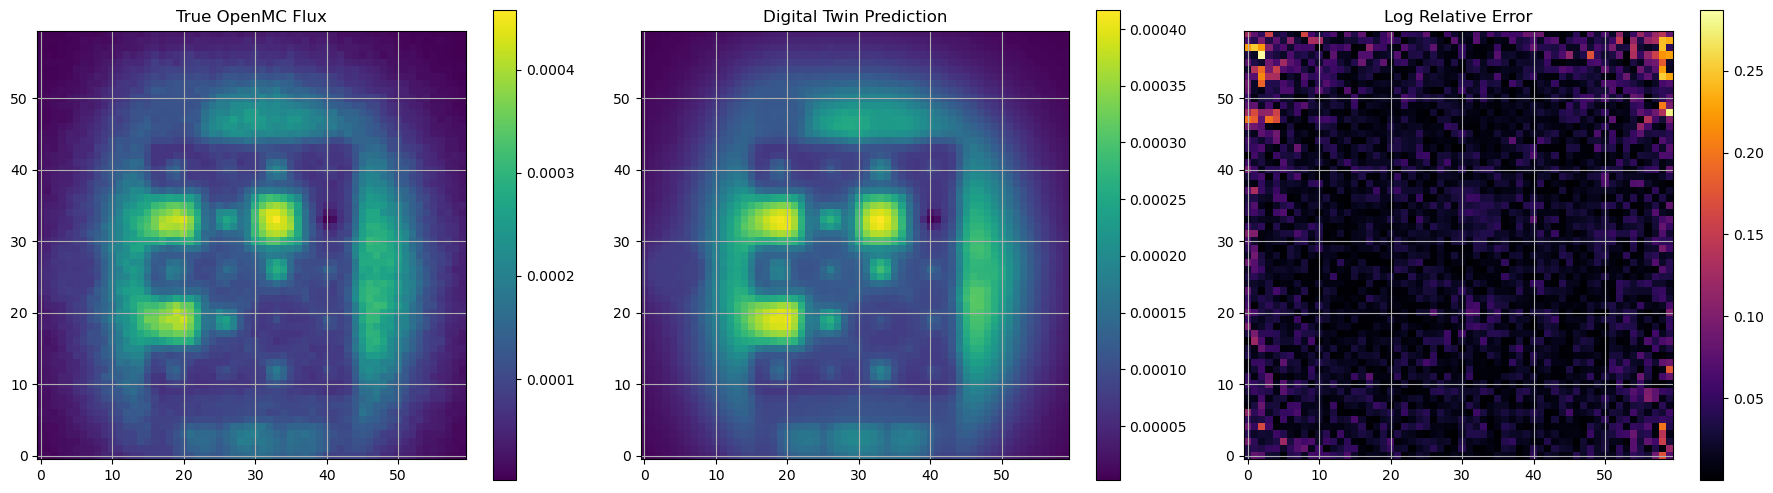

In [15]:
# Pick a random test case to visualize
test_idx = 3
input_params = X_test[test_idx].reshape(1, -1)

print(f"Simulating VR-1 State: Rods={input_params[0][:2]}, Water={input_params[0][2:]}")

# 1. Predict the 'r' coefficients for this state
predicted_coeffs = surrogate_model.predict(input_params).T # Shape: (r, 1)

# 2. Reconstruct the full 3D flux field!
reconstructed_flat = np.dot(U_r, predicted_coeffs)

# CORRECTED SHAPE: (Z, Y, X, Energy)
reconstructed_3d = reconstructed_flat.reshape((NZ, NY, NX, NG))

# 3. Load the true Monte Carlo result for comparison
# Force the case_id to be an integer to avoid the '.0' file path error
true_case_id = int(test_df.iloc[test_idx]["case_id"])
true_3d = load_flux_data(f'VR1_DT_Lab_Test_Data/results_case_{true_case_id}.npz')

# 4. Visualize the mid-plane Thermal Flux
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
z_mid = 35

# True Physics
im0 = axes[0].imshow(true_3d[z_mid, :, :, 0], origin='lower', cmap='viridis')
axes[0].set_title('True OpenMC Flux')
fig.colorbar(im0, ax=axes[0])

# Digital Twin Prediction
im1 = axes[1].imshow(reconstructed_3d[z_mid, :, :, 0], origin='lower', cmap='viridis')
axes[1].set_title('Digital Twin Prediction')
fig.colorbar(im1, ax=axes[1])

# Absolute Error
error = np.abs(true_3d[z_mid, :, :, 0] - reconstructed_3d[z_mid, :, :, 0])

# Log Relative Error (with small epsilon to avoid division by zero)
epsilon = 1e-10
relative_error = np.log10(error / (np.abs(true_3d[z_mid, :, :, 0]) + epsilon) + 1)
im2 = axes[2].imshow(relative_error, origin='lower', cmap='inferno')
axes[2].set_title('Log Relative Error')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# 9th Problem: "Digital Twin" ROM of VR-1

Play with the reduced order model that we created to predict flux across the reactor.

1. Where does flux change the most as you change each parameter? Why?
2. Change z-index as well to see how the flux looks at different heights in the reactor. What is a quick check we can do by changing z-index to see if we our ROM is modeling control rods correctly?

In [16]:
def run_digital_twin(cr1, cr2, dummy_water, fa_water, z_index=35):
    """Instantly predicts k-effective and plots the 3D flux field."""
    # 1. Format the input for the ML models
    input_state = np.array([[cr1, cr2, dummy_water, fa_water]])
    
    # 2. Predict Criticality
    predicted_keff = keff_model.predict(input_state)[0]
    
    # 3. Predict Modal Coefficients and Reconstruct Field
    predicted_coeffs = surrogate_model.predict(input_state).T
    reconstructed_flat = np.dot(U_r, predicted_coeffs)
    reconstructed_3d = reconstructed_flat.reshape((NZ, NY, NX, NG))
    
    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    im0 = axes[0].imshow(reconstructed_3d[z_index, :, :, 0], origin='lower', cmap='viridis')
    axes[0].set_title(f'Thermal Flux (Z={z_index})')
    fig.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(reconstructed_3d[z_index, :, :, 1], origin='lower', cmap='plasma')
    axes[1].set_title(f'Fast Flux (Z={z_index})')
    fig.colorbar(im1, ax=axes[1])
    
    plt.suptitle(f"Digital Twin Output | Estimated k-effective: {predicted_keff:.5f}", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Create the interactive object
interactive_twin = widgets.interactive(
    run_digital_twin,
    # Rods: 0.0 to 84.7 cm
    cr1=widgets.FloatSlider(value=42.35, min=0.0, max=84.7, step=0.1, description='CR 1 (cm):'),
    cr2=widgets.FloatSlider(value=42.35, min=0.0, max=84.7, step=0.1, description='CR 2 (cm):'),
    # Water: 0.50 to 1.00 multiplier
    dummy_water=widgets.FloatSlider(value=1.00, min=0.50, max=1.00, step=0.01, description='Dummy Water:'),
    fa_water=widgets.FloatSlider(value=1.00, min=0.50, max=1.00, step=0.01, description='FA Water:'),
    # Mesh Slicing
    z_index=widgets.IntSlider(value=35, min=0, max=69, step=1, description='Z-Slice:')
)

# Force the display
display(interactive_twin)

interactive(children=(FloatSlider(value=42.35, description='CR 1 (cm):', max=84.7), FloatSlider(value=42.35, d…